# Analizando el threshold
Los modelos de clasificación no generan directamente clasificaciones binarias, sino **probabilidades de pertenencia a una clase**. Para convertir estas probabilidades en etiquetas binarias, se utiliza un **threshold** o umbral, generalmente fijado en **0.5 por defecto**. Mosificar este umbral afecta significativamente las métricas: un threshold más bajo aumenta la sensibilidad (más verdaderos positivos, pero también más falsos positivos), mientras que un threshold más alto incrementa la especificidad (menos falsos positivos, pero también menos verdaderos positivos). 

En sklearn, hay dos formas de obtener predicciones:
- _y_pred= predict(X)_, que asigna cada instancia a una clase, en base a la probabilidad de pertenencia mayor. En clasificación binaria, esto es equivalente a usar un **threshol=0.5**
- _y_pred= predict_proba(X)_, más realista y flexible, que propociona probabilidades. Proporcina la probabilidad de la **Clase 0, _y_pred[:,0]** y la probabilidad de la **Clase 1, _y_pred[:,1]**


Por lo tanto, es crucial elegir el umbral adecuado según el contexto y los objetivos del modelo.

## Ejemplo 1
Crear un modelo sencillo de regresión logística para la base de datos _Pime Indians Diabets Datasets_ y analiza la evolución de las medidas de bondad de ajuste en función del threshold establecido.

In [6]:
display(Markdown(f'Usando la base de datos _Pime Indians Diabets Datasets_ disponible en ({url}), aplica un proceso de regresión'))

Usando la base de datos _Pime Indians Diabets Datasets_ disponible en (https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv), aplica un proceso de regresión

In [5]:
import pandas as pd

# Cargar el dataset Pima Indians Diabetes desde un archivo CSV
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
df = pd.read_csv(url, header=None)
df.columns

Index([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype='int64')

In [7]:
# Asumir que la última columna es la variable objetivo
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print(X.head())
print(y.head())

   0    1   2   3    4     5      6   7
0  6  148  72  35    0  33.6  0.627  50
1  1   85  66  29    0  26.6  0.351  31
2  8  183  64   0    0  23.3  0.672  32
3  1   89  66  23   94  28.1  0.167  21
4  0  137  40  35  168  43.1  2.288  33
0    1
1    0
2    1
3    0
4    1
Name: 8, dtype: int64


In [9]:
## Análisis rápido sobre las características de la base
print(f'Número de filas y columnas {df.shape}') # Mostrar la forma del DataFrame (número de filas y columnas)
print(f'Tipo de los datos {df.dtypes}') # Mostrar los tipos de datos de las columnas
print(f'Estadísticas descriptivas {df.describe()}') # Mostrar estadísticas descriptivas del DataFrame
print(f'Matriz de correlación {df.corr()}') # Calcular la matriz de correlación entre las características numéricas
print(f'Número de muestras por categoría {df.groupby(df.iloc[:, -1]).size()}') # Contar el número de muestras por categoría

Número de filas y columnas (768, 9)
Tipo de los datos 0      int64
1      int64
2      int64
3      int64
4      int64
5    float64
6    float64
7      int64
8      int64
dtype: object
Estadísticas descriptivas                 0           1           2           3           4           5  \
count  768.000000  768.000000  768.000000  768.000000  768.000000  768.000000   
mean     3.845052  120.894531   69.105469   20.536458   79.799479   31.992578   
std      3.369578   31.972618   19.355807   15.952218  115.244002    7.884160   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      1.000000   99.000000   62.000000    0.000000    0.000000   27.300000   
50%      3.000000  117.000000   72.000000   23.000000   30.500000   32.000000   
75%      6.000000  140.250000   80.000000   32.000000  127.250000   36.600000   
max     17.000000  199.000000  122.000000   99.000000  846.000000   67.100000   

                6           7           8  
count  768.0000

## OJO:

Al tratarse de un ejemplo ilustrativo, no se hará la división en tr/ts, y todas las medidas de ajuste se calcularán directamente sobre la base de datos completa. Esto sería INCORRECTO en un proceso de ML.

In [12]:
# Establecer una semilla concreta (en este caso, 12345)
SEED = 12345

# Para aleatorización en Python
import random
random.seed(SEED)

# Para aleatorización en numpy
import numpy as np
np.random.seed(SEED)

In [14]:
from sklearn.linear_model import LogisticRegression
# Definir el modelo de regresión, lo hacemos sin parámetros
model = LogisticRegression(random_state=SEED)
#¿qué pasa al no establecer iteraciones?
#model = LogisticRegression(max_iter=2000,random_state=SEED)
#Entrenar el modelo
model.fit(X, y)

#Obtener predicciones
y_pred = model.predict_proba(X)[:,1]

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## OJO: 
Si las predicciones se obtienen como probabilidad, hay que binarizarlas antes de calcular las medidas de bondad de ajuste. 
Para ello, hay que aplicar un threshold. A continuación se muestra el **error** que se obtiene al comparar un valor binario (etiqueta real) con una probabilidad.

Sí se puede trabajar con probabilidades para calcular la curva ROC y el AUC, ya que el sistema escoge los thresholsd a utilizar.

In [16]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, auc, recall_score, precision_score
accuracy = accuracy_score(y, y_pred)
print(f"Accuracy: {accuracy}")

ValueError: Classification metrics can't handle a mix of binary and continuous targets

In [18]:
from sklearn.metrics import roc_curve, auc
#roc_curve calcula las tasas fpr y tpr para distintos punto de corte, establecidos por el sistema dependiendo de los datos
fpr, tpr, thresholds = roc_curve(y, y_pred)
print(f"Tasa de falsos positivos: {fpr[:5]}")
print(f"Tasa de verdaderos positivos: {tpr[:5]}")
print(f"Puntos de corte (thresholds): {thresholds}")

Tasa de falsos positivos: [0.    0.    0.002 0.002 0.004]
Tasa de verdaderos positivos: [0.         0.00373134 0.00373134 0.00746269 0.00746269]
Puntos de corte (thresholds): [       inf 0.99559075 0.97969108 0.97195178 0.97068298 0.94141949
 0.93664514 0.92450431 0.9211687  0.89622258 0.89501877 0.89175934
 0.89048782 0.86601724 0.8656219  0.84922794 0.84839084 0.81722573
 0.81618109 0.79230176 0.79024054 0.77391918 0.77376776 0.75162514
 0.74634828 0.74511222 0.74345538 0.74052767 0.73422975 0.72220293
 0.71584999 0.70888398 0.70664857 0.70484883 0.70386826 0.69354804
 0.69291971 0.69260833 0.69097755 0.68341519 0.68324562 0.6791367
 0.67348616 0.66862736 0.66398281 0.66326175 0.66001333 0.65844208
 0.65545458 0.64631287 0.64606874 0.64326193 0.6402997  0.63727977
 0.63697958 0.63228699 0.63181378 0.62315198 0.62071794 0.61433136
 0.60649589 0.59844346 0.59327993 0.584679   0.58313126 0.57536283
 0.56708779 0.5558114  0.55129673 0.54025451 0.54018454 0.53874552
 0.53735998 0.52794401

## Solución
Para calcular el resto de medidas de bondad de ajuste, escoger threshold y binarizar las probabilidades

## ¿Qué umbral utilizar?
Si no hay ninguna especificación propia del problema, o se quiere tomar una decisión rápida, tras conocer _tpr_ y _fpr_, una opción es elegir el umbral en función del punto de equilibrio máximo (donde la distancia entre la curva ROC y la diagonal es mayor), aplicando el **índice de Youden: tpr - fpr**

In [20]:
import numpy as np

# Calcular el índice de Youden para cada umbral
youden_index = tpr - fpr

# Encontrar el umbral que maximiza el índice de Youden
best_threshold = thresholds[np.argmax(youden_index)]

print(f"Umbral óptimo según el índice de Youden: {best_threshold}")


Umbral óptimo según el índice de Youden: 0.32488345564443005


Los elementos de la matriz de confusión son tn: 373; fp: 127; fn: 58 y tp: 210.


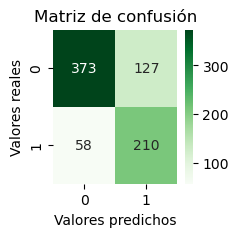

Accuracy: 0.7591145833333334
Precisión: 0.6231454005934718
F1_score: 0.6942148760330579
Recall/sensibilidad: 0.7835820895522388


In [22]:
threshold=best_threshold
y_pred_binary = (y_pred >= threshold).astype(int)

#matriz de confusión
cm = confusion_matrix(y, y_pred_binary)
tn, fp, fn, tp= cm[0][0], cm[0][1], cm[1][0], cm[1][1]     
print(f"Los elementos de la matriz de confusión son tn: {tn}; fp: {fp}; fn: {fn} y tp: {tp}.")


import matplotlib.pyplot as plt
import seaborn as sns
clases = ['0', '1']

# Crear un mapa de calor para mejorar la visualización
plt.figure(figsize=(2, 2))
sns.heatmap(cm, annot=True, cmap='Greens', fmt='g', xticklabels=clases, yticklabels=clases)
plt.xlabel('Valores predichos')
plt.ylabel('Valores reales')
plt.title('Matriz de confusión')
plt.show()
plt.close()

accuracy = accuracy_score(y, y_pred_binary)
print(f"Accuracy: {accuracy}")

precision=precision_score(y, y_pred_binary)
print(f"Precisión: {precision}")

f1=f1_score(y, y_pred_binary)
print(f"F1_score: {f1}")

recall = recall_score(y, y_pred_binary)
print(f"Recall/sensibilidad: {recall}")

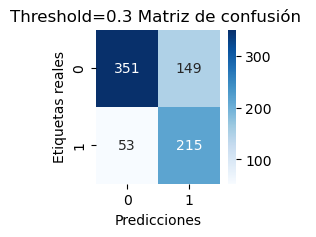

Accuracy: 0.7369791666666666
Precisión: 0.5906593406593407
F1_score: 0.680379746835443
Recall/sensibilidad: 0.8022388059701493


/var/folders/yk/65m66v4j5_l_ppkvs0q7j9cw0000gn/T/ipykernel_3881/2250965981.py:45: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, new_row], ignore_index=True)


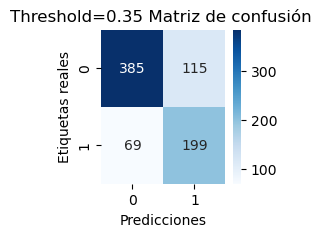

Accuracy: 0.7604166666666666
Precisión: 0.6337579617834395
F1_score: 0.6838487972508591
Recall/sensibilidad: 0.7425373134328358


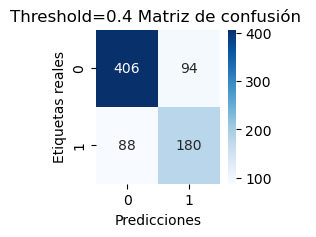

Accuracy: 0.7630208333333334
Precisión: 0.656934306569343
F1_score: 0.6642066420664207
Recall/sensibilidad: 0.6716417910447762


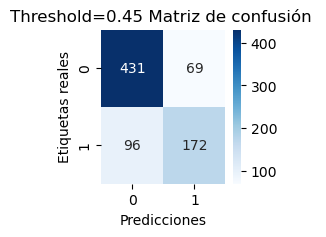

Accuracy: 0.78515625
Precisión: 0.7136929460580913
F1_score: 0.6758349705304518
Recall/sensibilidad: 0.6417910447761194


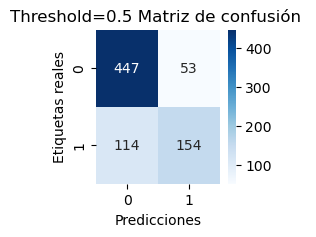

Accuracy: 0.7825520833333334
Precisión: 0.7439613526570048
F1_score: 0.6484210526315789
Recall/sensibilidad: 0.5746268656716418


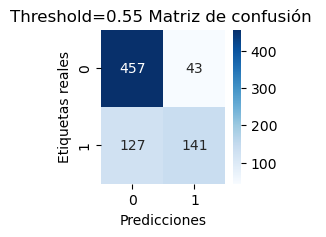

Accuracy: 0.7786458333333334
Precisión: 0.7663043478260869
F1_score: 0.6238938053097345
Recall/sensibilidad: 0.5261194029850746


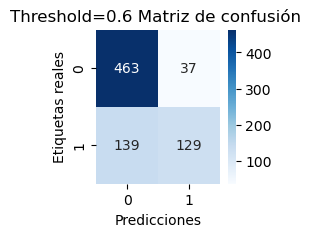

Accuracy: 0.7708333333333334
Precisión: 0.7771084337349398
F1_score: 0.5944700460829493
Recall/sensibilidad: 0.48134328358208955


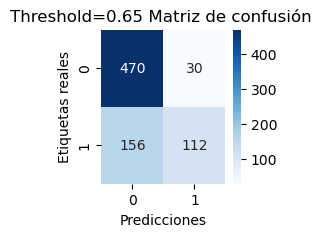

Accuracy: 0.7578125
Precisión: 0.7887323943661971
F1_score: 0.5463414634146342
Recall/sensibilidad: 0.417910447761194


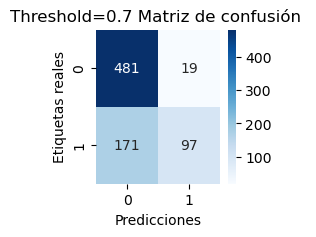

Accuracy: 0.7526041666666666
Precisión: 0.8362068965517241
F1_score: 0.5052083333333334
Recall/sensibilidad: 0.3619402985074627


In [24]:
 # Iterar a través de thresholds para comparar resultados
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]
results_df = pd.DataFrame(columns=["FP", "FN", "TP", "TN","recall","precision","accuracy","f1","TH"])
for threshold in thresholds:
    y_pred_binary = (y_pred >= threshold).astype(int)
    clases = ['0', '1']
    cm = confusion_matrix(y, y_pred_binary)
    fp, fn, tp, tn = cm[0][1], cm[1][0], cm[1][1], cm[0][0]
 # Create a heatmap of the confusion matrix
    plt.figure(figsize=(2, 2))
    sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', xticklabels=clases, yticklabels=clases)
    plt.xlabel('Predicciones')
    plt.ylabel('Etiquetas reales')
    plt.title('Threshold=' + str(threshold) + ' Matriz de confusión ')
    #si se quisieran guardar las imágenes
    #filename = 'TH=' + str(threshold) + ' Confusion Matrix ' + '.png'
    #filename = filename.replace("\n", "_").replace(" ", "_").replace(".", "") 
        
    plt.show()
    plt.close()

    accuracy = accuracy_score(y, y_pred_binary)
    print(f"Accuracy: {accuracy}")

    precision=precision_score(y, y_pred_binary)
    print(f"Precisión: {precision}")
    
    f1=f1_score(y, y_pred_binary)
    print(f"F1_score: {f1}")

    recall = recall_score(y, y_pred_binary)
    print(f"Recall/sensibilidad: {recall}")
    new_row = pd.DataFrame({
                "FP": [fp],
                "FN": [fn],
                "TP": [tp],
                "TN": [tn],
                "recall": [recall],
                "precision": [precision],
                "accuracy": [accuracy],
                "f1": [f1],                
                "TH": [threshold],
            })
      # Concatenar la nueva fila al DataFrame de resultados
    results_df = pd.concat([results_df, new_row], ignore_index=True)

## Representamos la evolución

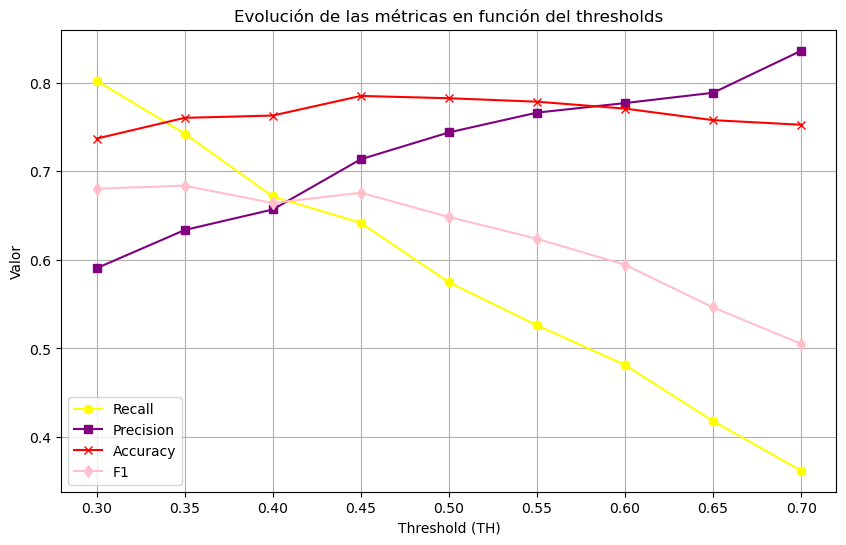

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(10, 6))

# Graficar cada métrica con su respectiva coloración y marcador
plt.plot(results_df['TH'], results_df['recall'], label='Recall', color='yellow', marker='o')
plt.plot(results_df['TH'], results_df['precision'],label='Precision', color='purple', marker='s')
plt.plot(results_df['TH'], results_df['accuracy'], label='Accuracy', color='red', marker='x')
plt.plot(results_df['TH'], results_df['f1'], label='F1', color='pink', marker='d')

# Configuración de la gráfica
plt.title('Evolución de las métricas en función del thresholds')
plt.xlabel('Threshold (TH)')
plt.ylabel('Valor')
plt.legend()

# Mostrar la cuadrícula
plt.grid(True)

# Mostrar la gráfica
plt.show()